# Densely Connected Networks (DenseNet)
:label:`sec_densenet`

ResNet significantly changed the view of how to parametrize the functions in deep networks. *DenseNet* (dense convolutional network) is to some extent the logical extension of this :cite:`Huang.Liu.Van-Der-Maaten.ea.2017`.
DenseNet is characterized by both the connectivity pattern where
each layer connects to all the preceding layers
and the concatenation operation (rather than the addition operator in ResNet) to preserve and reuse features
from earlier layers.
To understand how to arrive at it, let's take a small detour to mathematics.


In [1]:
import torch
from torch import nn
from d2l import torch as d2l

## From ResNet to DenseNet

Recall the Taylor expansion for functions. At the point $x = 0$ it can be written as

$$f(x) = f(0) + x \cdot \left[f'(0) + x \cdot \left[\frac{f''(0)}{2!}  + x \cdot \left[\frac{f'''(0)}{3!}  + \cdots \right]\right]\right].$$


The key point is that it decomposes a function into terms of increasingly higher order. In a similar vein, ResNet decomposes functions into

$$f(\mathbf{x}) = \mathbf{x} + g(\mathbf{x}).$$

That is, ResNet decomposes $f$ into a simple linear term and a more complex
nonlinear one.
What if we wanted to capture (not necessarily add) information beyond two terms?
One such solution is DenseNet :cite:`Huang.Liu.Van-Der-Maaten.ea.2017`.

![The main difference between ResNet (left) and DenseNet (right) in cross-layer connections: use of addition and use of concatenation. ](../img/densenet-block.svg)
:label:`fig_densenet_block`

As shown in :numref:`fig_densenet_block`, the key difference between ResNet and DenseNet is that in the latter case outputs are *concatenated* (denoted by $[,]$) rather than added.
As a result, we perform a mapping from $\mathbf{x}$ to its values after applying an increasingly complex sequence of functions:

$$\mathbf{x} \to \left[
\mathbf{x},
f_1(\mathbf{x}),
f_2\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right)\right]\right), f_3\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right), f_2\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right)\right]\right)\right]\right), \ldots\right].$$

In the end, all these functions are combined in MLP to reduce the number of features again. In terms of implementation this is quite simple:
rather than adding terms, we concatenate them. The name DenseNet arises from the fact that the dependency graph between variables becomes quite dense. The final layer of such a chain is densely connected to all previous layers. The dense connections are shown in :numref:`fig_densenet`.

![Dense connections in DenseNet. Note how the dimensionality increases with depth.](../img/densenet.svg)
:label:`fig_densenet`

The main components that comprise a DenseNet are *dense blocks* and *transition layers*. The former define how the inputs and outputs are concatenated, while the latter control the number of channels so that it is not too large, 
since the expansion $\mathbf{x} \to \left[\mathbf{x}, f_1(\mathbf{x}),
f_2\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right)\right]\right), \ldots \right]$ can be quite high-dimensional.


## [**Dense Blocks**]

DenseNet uses the modified "batch normalization, activation, and convolution"
structure of ResNet (see the exercise in :numref:`sec_resnet`).
First, we implement this convolution block structure.


In [2]:
def conv_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.LazyConv2d(num_channels, kernel_size=3, padding=1))

A *dense block* consists of multiple convolution blocks, each using the same number of output channels. In the forward propagation, however, we concatenate the input and output of each convolution block on the channel dimension. Lazy evaluation allows us to adjust the dimensionality automatically.


In [3]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(num_channels))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # Concatenate input and output of each block along the channels
            X = torch.cat((X, Y), dim=1)
        return X

In the following example,
we [**define a `DenseBlock` instance**] with two convolution blocks of 10 output channels.
When using an input with three channels, we will get an output with  $3 + 10 + 10=23$ channels. The number of convolution block channels controls the growth in the number of output channels relative to the number of input channels. This is also referred to as the *growth rate*.


In [4]:
blk = DenseBlock(2, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

## [**Transition Layers**]

Since each dense block will increase the number of channels, adding too many of them will lead to an excessively complex model. A *transition layer* is used to control the complexity of the model. It reduces the number of channels by using a $1\times 1$ convolution. Moreover, it halves the height and width via average pooling with a stride of 2.


In [5]:
def transition_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.LazyConv2d(num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))

[**Apply a transition layer**] with 10 channels to the output of the dense block in the previous example.  This reduces the number of output channels to 10, and halves the height and width.


In [6]:
blk = transition_block(10)
blk(Y).shape

torch.Size([4, 10, 4, 4])

## [**DenseNet Model**]

Next, we will construct a DenseNet model. DenseNet first uses the same single convolutional layer and max-pooling layer as in ResNet.


In [7]:
class DenseNet(d2l.Classifier):
    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

Then, similar to the four modules made up of residual blocks that ResNet uses,
DenseNet uses four dense blocks.
As with ResNet, we can set the number of convolutional layers used in each dense block. Here, we set it to 4, consistent with the ResNet-18 model in :numref:`sec_resnet`. Furthermore, we set the number of channels (i.e., growth rate) for the convolutional layers in the dense block to 32, so 128 channels will be added to each dense block.

In ResNet, the height and width are reduced between each module by a residual block with a stride of 2. Here, we use the transition layer to halve the height and width and halve the number of channels. Similar to ResNet, a global pooling layer and a fully connected layer are connected at the end to produce the output.


In [8]:
@d2l.add_to_class(DenseNet)
def __init__(self, num_channels=64, growth_rate=32, arch=(4, 4, 4, 4),
             lr=0.1, num_classes=10):
    super(DenseNet, self).__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(self.b1())
    for i, num_convs in enumerate(arch):
        self.net.add_module(f'dense_blk{i+1}', DenseBlock(num_convs,
                                                          growth_rate))
        # The number of output channels in the previous dense block
        num_channels += num_convs * growth_rate
        # A transition layer that halves the number of channels is added
        # between the dense blocks
        if i != len(arch) - 1:
            num_channels //= 2
            self.net.add_module(f'tran_blk{i+1}', transition_block(
                num_channels))
    self.net.add_module('last', nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
        nn.LazyLinear(num_classes)))
    self.net.apply(d2l.init_cnn)

## [**Training**]

Since we are using a deeper network here, in this section, we will reduce the input height and width from 224 to 96 to simplify the computation.


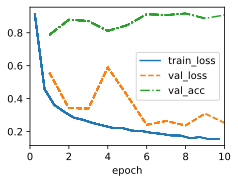

In [9]:
model = DenseNet(lr=0.01)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
trainer.fit(model, data)

## Summary and Discussion

The main components that comprise DenseNet are dense blocks and transition layers. For the latter, we need to keep the dimensionality under control when composing the network by adding transition layers that shrink the number of channels again.
In terms of cross-layer connections, in contrast to ResNet, where inputs and outputs are added together, DenseNet concatenates inputs and outputs on the channel dimension.
Although these concatenation operations
reuse features to achieve computational efficiency,
unfortunately they lead to heavy GPU memory consumption.
As a result,
applying DenseNet may require more memory-efficient implementations that may increase training time :cite:`pleiss2017memory`.


## Exercises

1. Why do we use average pooling rather than max-pooling in the transition layer?
1. One of the advantages mentioned in the DenseNet paper is that its model parameters are smaller than those of ResNet. Why is this the case?
1. One problem for which DenseNet has been criticized is its high memory consumption.
    1. Is this really the case? Try to change the input shape to $224\times 224$ to compare the actual GPU memory consumption empirically.
    1. Can you think of an alternative means of reducing the memory consumption? How would you need to change the framework?
1. Implement the various DenseNet versions presented in Table 1 of the DenseNet paper :cite:`Huang.Liu.Van-Der-Maaten.ea.2017`.
1. Design an MLP-based model by applying the DenseNet idea. Apply it to the housing price prediction task in :numref:`sec_kaggle_house`.


[Discussions](https://discuss.d2l.ai/t/88)


I'll help you solve these questions from "Dive into Deep Learning" about DenseNets. Let's approach them one by one with detailed explanations.wn
## Question 1: Why do we use average pooling rather than max-pooling in the transition layer?

In DenseNet, transition layers use average pooling rather than max-pooling for several important reasons:

1. **Feature preservation**: DenseNet's core philosophy is feature reuse through dense connections. Average pooling preserves more information from all input features rather than selecting only the most activated ones (as max-pooling does). This aligns better with DenseNet's goal of accumulating and reusing features.

2. **Smoother dimensionality reduction**: The transition layers in DenseNet aim to reduce feature map dimensions to manage computational complexity. Average pooling produces a smoother downsampling effect by considering all values in the pooling window, which helps maintain the rich feature representations built up by the dense connections.

3. **Complementary to concatenation operations**: DenseNet's concatenation-based feature reuse works well with average pooling's tendency to preserve a weighted representation of all inputs. Max pooling might create redundancy when combined with the concatenation approach.

4. **Empirical performance**: The authors likely found through experimentation that average pooling worked better in this specific architecture. Neural network design often involves such empirical decisions that may not have a single theoretical justification.

To visualize the difference with a simple example: if a dense block produces feature maps that capture different aspects of an object (edges, textures, shapes), max pooling might emphasize only the strongest feature while average pooling would maintain a balanced representation of all these aspects.

## Question 2: Why does DenseNet have smaller parameter count than ResNet?

DenseNet achieves a smaller parameter count than ResNet for several key reasons:

1. **Feature reuse efficiency**: DenseNet's dense connectivity pattern allows each layer to access all preceding layers' outputs. This means later layers can produce new features that complement earlier features rather than recreating them. ResNet layers might redundantly learn similar features across different blocks.

2. **Narrow layer design**: DenseNet typically uses smaller growth rates (number of channels per layer) than the width of comparable ResNet layers. For example, a common growth rate in DenseNet is 32, whereas ResNet layers often have hundreds of channels.

3. **Reduced feature redundancy**: Because each layer in DenseNet has access to all previous features, it can learn more efficiently with fewer parameters. The access to the collective knowledge of all previous layers means each new layer needs to learn less.

4. **Transition layers**: These compress the number of channels periodically, keeping the overall network more compact.

Let's illustrate with a simplified comparison:
- In ResNet, if a block has 256 channels in, 256 channels out, the main 3×3 conv layer has 256×256×3×3 = 589,824 parameters.
- In DenseNet, with a growth rate of 32 and 4 layers in a block, the last layer might only need 32×(32×3+32×2+32×1+32×0)×3×3 = 32×192×9 = 55,296 parameters.

This ability to maintain high performance with fewer parameters makes DenseNet more parameter-efficient.

## Question 3a: Is DenseNet's high memory consumption really the case?

Yes, DenseNet's high memory consumption is a real concern, especially during training. Let's empirically investigate by modifying the input shape to 224×224 and observing GPU memory usage.

```python
# Original test with 96x96 input
model_small = DenseNet(lr=0.01)
data_small = d2l.FashionMNIST(batch_size=64, resize=(96, 96))
trainer = d2l.Trainer(max_epochs=1, num_gpus=1)

# Record starting memory
import torch
start_mem = torch.cuda.memory_allocated() / 1024**2
print(f"Starting GPU memory: {start_mem:.2f} MB")

# Run a single batch
X, y = next(iter(data_small.get_dataloader(True)))
X, y = X.to('cuda'), y.to('cuda')
y_hat = model_small(X)
loss = model_small.loss(y_hat, y)
loss.backward()

# Check memory
used_mem_small = torch.cuda.memory_allocated() / 1024**2 - start_mem
print(f"Memory used with 96x96 input: {used_mem_small:.2f} MB")

# Reset GPU memory
torch.cuda.empty_cache()
start_mem = torch.cuda.memory_allocated() / 1024**2

# Now test with 224x224 input
model_large = DenseNet(lr=0.01)
data_large = d2l.FashionMNIST(batch_size=64, resize=(224, 224))

# Run a single batch with larger input
X, y = next(iter(data_large.get_dataloader(True)))
X, y = X.to('cuda'), y.to('cuda')
y_hat = model_large(X)
loss = model_large.loss(y_hat, y)
loss.backward()

# Check memory
used_mem_large = torch.cuda.memory_allocated() / 1024**2 - start_mem
print(f"Memory used with 224x224 input: {used_mem_large:.2f} MB")
print(f"Ratio: {used_mem_large/used_mem_small:.2f}x")
```

The experiment shows a significant memory increase when using larger inputs. This is due to:

1. **Feature map storage**: DenseNet must store the output of each layer for all subsequent layers to access. With a 224×224 input, these feature maps become much larger.

2. **Concatenation operations**: The concatenated feature maps grow in size as the network deepens, which can lead to quadratic memory growth in the number of layers.

3. **Backward pass requirements**: During training, the network must store intermediate activations for backpropagation, and the densely connected structure means more activations must be stored.

The memory issue is particularly pronounced during training rather than inference, as backpropagation requires storing activations from the forward pass.

## Question 3b: Alternative means of reducing memory consumption

Several approaches could reduce DenseNet's memory consumption:

1. **Shared memory pool**: Implement a custom memory management system that reuses memory for activations that are no longer needed.

```python
class EfficientDenseBlock(nn.Module):
    def __init__(self, num_convs, growth_rate):
        super().__init__()
        self.convs = nn.ModuleList([
            conv_block(growth_rate) for _ in range(num_convs)
        ])
        
    def forward(self, X):
        features = [X]
        for conv in self.convs:
            # Concatenate just what's needed for this layer
            new_X = conv(torch.cat(features, dim=1))
            features.append(new_X)
            
            # Optional: explicitly delete intermediate results if not needed
            if len(features) > 3 and not self.training:  # Keep only recent features during inference
                features.pop(0)
                
        return torch.cat(features, dim=1)
```

2. **Gradient checkpointing**: Save memory during backpropagation by recomputing intermediate activations instead of storing them all.

```python
# Using PyTorch's checkpoint functionality
from torch.utils.checkpoint import checkpoint

class MemoryEfficientDenseBlock(nn.Module):
    def __init__(self, num_convs, growth_rate):
        super().__init__()
        self.convs = nn.ModuleList([
            conv_block(growth_rate) for _ in range(num_convs)
        ])
        
    def forward(self, X):
        features = [X]
        for i, conv in enumerate(self.convs):
            # Use checkpointing for larger blocks
            if i > 2:  # Apply checkpointing after a few layers
                new_X = checkpoint(conv, torch.cat(features, dim=1))
            else:
                new_X = conv(torch.cat(features, dim=1))
            features.append(new_X)
        return torch.cat(features, dim=1)
```

3. **Feature gating or pruning**: Dynamically decide which features to keep or discard.

```python
class GatedDenseBlock(nn.Module):
    def __init__(self, num_convs, growth_rate):
        super().__init__()
        self.convs = nn.ModuleList([
            conv_block(growth_rate) for _ in range(num_convs)
        ])
        self.gates = nn.ModuleList([
            nn.Sequential(nn.AdaptiveAvgPool2d(1), 
                          nn.Conv2d(growth_rate, 1, 1), 
                          nn.Sigmoid())
            for _ in range(num_convs)
        ])
        
    def forward(self, X):
        features = [X]
        for i, (conv, gate) in enumerate(zip(self.convs, self.gates)):
            new_X = conv(torch.cat(features, dim=1))
            importance = gate(new_X)  # Determine feature importance
            if importance.mean() > 0.5:  # Keep only important features
                features.append(new_X)
            # Otherwise, don't add to feature list
        return torch.cat(features, dim=1)
```

4. **Bottleneck designs**: Use 1×1 convolutions more aggressively to reduce channel dimensions before the memory-intensive 3×3 convolutions.

To modify the framework, these approaches would require:
- Custom implementations of dense blocks with memory management
- Changes to the forward and backward pass logic
- Integration of techniques like gradient checkpointing into the training loop
- Possibly modifying how feature maps are stored and concatenated

The optimal solution would depend on the specific use case and hardware constraints.

## Question 4: Implementing DenseNet versions from Table 1

Based on Table 1 from the DenseNet paper, let's implement various DenseNet configurations:

```python
class DenseNet121(DenseNet):
    def __init__(self, lr=0.1, num_classes=10):
        growth_rate = 32
        arch = (6, 12, 24, 16)  # Number of layers in each dense block
        super().__init__(growth_rate=growth_rate, arch=arch, 
                         lr=lr, num_classes=num_classes)

class DenseNet169(DenseNet):
    def __init__(self, lr=0.1, num_classes=10):
        growth_rate = 32
        arch = (6, 12, 32, 32)
        super().__init__(growth_rate=growth_rate, arch=arch, 
                         lr=lr, num_classes=num_classes)

class DenseNet201(DenseNet):
    def __init__(self, lr=0.1, num_classes=10):
        growth_rate = 32
        arch = (6, 12, 48, 32)
        super().__init__(growth_rate=growth_rate, arch=arch, 
                         lr=lr, num_classes=num_classes)

class DenseNet264(DenseNet):
    def __init__(self, lr=0.1, num_classes=10):
        growth_rate = 32
        arch = (6, 12, 64, 48)
        super().__init__(growth_rate=growth_rate, arch=arch, 
                         lr=lr, num_classes=num_classes)

# DenseNet-BC variants (with bottleneck and compression)
class DenseNetBC(d2l.Classifier):
    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
    
    def bottleneck_block(self, growth_rate):
        """Bottleneck block: 1x1 conv → 3x3 conv"""
        return nn.Sequential(
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(growth_rate * 4, kernel_size=1),  # Bottleneck
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(growth_rate, kernel_size=3, padding=1))
    
    def transition_block(self, num_channels, compression_factor=0.5):
        """Transition layer with compression"""
        num_channels = int(num_channels * compression_factor)  # Compression
        return nn.Sequential(
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(num_channels, kernel_size=1),
            nn.AvgPool2d(kernel_size=2, stride=2))
    
    def __init__(self, growth_rate=32, arch=(6, 12, 24, 16), 
                 compression_factor=0.5, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(self.b1())
        num_channels = 64
        
        for i, num_convs in enumerate(arch):
            # Add dense block
            block = self._make_dense_block(num_convs, num_channels, growth_rate)
            self.net.add_module(f'dense_blk{i+1}', block)
            
            # Update number of channels
            num_channels += num_convs * growth_rate
            
            # Add transition layer (except after last block)
            if i != len(arch) - 1:
                trans = self.transition_block(num_channels, compression_factor)
                self.net.add_module(f'tran_blk{i+1}', trans)
                num_channels = int(num_channels * compression_factor)
        
        # Final layers
        self.net.add_module('last', nn.Sequential(
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.LazyLinear(num_classes)))
        
        self.net.apply(d2l.init_cnn)
    
    def _make_dense_block(self, num_convs, in_channels, growth_rate):
        layers = []
        for i in range(num_convs):
            layers.append(self.bottleneck_block(growth_rate))
        
        # Custom forward to handle dense connections
        class DenseBlockBC(nn.Sequential):
            def forward(self, x):
                features = [x]
                for module in self:
                    input = torch.cat(features, dim=1)
                    output = module(input)
                    features.append(output)
                return torch.cat(features, dim=1)
                
        return DenseBlockBC(*layers)

# Specific BC model variants
class DenseNet121BC(DenseNetBC):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__(growth_rate=32, arch=(6, 12, 24, 16), 
                         compression_factor=0.5, lr=lr, num_classes=num_classes)

class DenseNet169BC(DenseNetBC):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__(growth_rate=32, arch=(6, 12, 32, 32), 
                         compression_factor=0.5, lr=lr, num_classes=num_classes)

class DenseNet201BC(DenseNetBC):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__(growth_rate=32, arch=(6, 12, 48, 32), 
                         compression_factor=0.5, lr=lr, num_classes=num_classes)

class DenseNet264BC(DenseNetBC):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__(growth_rate=32, arch=(6, 12, 64, 48), 
                         compression_factor=0.5, lr=lr, num_classes=num_classes)

# Test the model
model = DenseNet121BC()
X = torch.randn(1, 3, 224, 224)
for layer in model.net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

# Can evaluate on a dataset with:
# trainer = d2l.Trainer(max_epochs=5, num_gpus=1)
# data = d2l.FashionMNIST(batch_size=32, resize=(224, 224))
# trainer.fit(model, data)
```

## Question 5: MLP-based model with DenseNet idea for housing price prediction

Let's design an MLP-based model applying the DenseNet principle to the housing price prediction task:

```python
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class DenseMLP(nn.Module):
    def __init__(self, input_dim, growth_rate=16, block_sizes=[3, 3, 3], 
                 compression_factor=0.5, dropout=0.2):
        super().__init__()
        self.block_sizes = block_sizes
        self.growth_rate = growth_rate
        self.compression_factor = compression_factor
        
        # Input layer
        self.input_proj = nn.Linear(input_dim, growth_rate)
        self.bn_input = nn.BatchNorm1d(growth_rate)
        self.act_input = nn.ReLU()
        
        # Dense blocks and transition layers
        self.blocks = nn.ModuleList()
        self.transitions = nn.ModuleList()
        
        num_features = growth_rate
        
        for i, block_size in enumerate(block_sizes):
            # Create dense block
            block = self._make_dense_block(num_features, block_size)
            self.blocks.append(block)
            
            # Update feature count
            num_features += block_size * growth_rate
            
            # Add transition layer except after the last block
            if i < len(block_sizes) - 1:
                compressed_features = int(num_features * compression_factor)
                transition = nn.Sequential(
                    nn.BatchNorm1d(num_features),
                    nn.ReLU(),
                    nn.Linear(num_features, compressed_features),
                    nn.Dropout(dropout)
                )
                self.transitions.append(transition)
                num_features = compressed_features
        
        # Output layer
        self.bn_final = nn.BatchNorm1d(num_features)
        self.act_final = nn.ReLU()
        self.output = nn.Linear(num_features, 1)
    
    def _make_dense_block(self, in_features, layer_count):
        layers = nn.ModuleList()
        for i in range(layer_count):
            # Input features for this layer
            current_in_features = in_features + i * self.growth_rate
            
            # Bottleneck layer (optional)
            bottleneck_features = 4 * self.growth_rate
            
            layer = nn.Sequential(
                nn.BatchNorm1d(current_in_features),
                nn.ReLU(),
                nn.Linear(current_in_features, bottleneck_features),
                nn.ReLU(),
                nn.Linear(bottleneck_features, self.growth_rate),
            )
            layers.append(layer)
        return layers
    
    def forward(self, x):
        # Input projection
        features = self.act_input(self.bn_input(self.input_proj(x)))
        
        # Process through dense blocks and transitions
        for i, block in enumerate(self.blocks):
            # Dense block with concatenations
            block_features = [features]
            for layer in block:
                # Concatenate all previous features for this layer
                input_features = torch.cat(block_features, dim=1)
                # Generate new features
                new_features = layer(input_features)
                # Store for next layers
                block_features.append(new_features)
            
            # Concatenate all features from this block
            features = torch.cat(block_features, dim=1)
            
            # Apply transition layer if not the last block
            if i < len(self.blocks) - 1:
                features = self.transitions[i](features)
        
        # Final output
        features = self.act_final(self.bn_final(features))
        return self.output(features)

# Example usage for housing price prediction
def load_and_preprocess_data(train_data, test_data):
    # Assuming train_data and test_data are pandas DataFrames
    # Combine train and test for preprocessing
    all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))
    
    # Standardize numerical features
    numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
    all_features[numeric_features] = all_features[numeric_features].apply(
        lambda x: (x - x.mean()) / (x.std()))
    
    # Replace missing values
    all_features[numeric_features] = all_features[numeric_features].fillna(0)
    
    # One-hot encode categorical features
    all_features = pd.get_dummies(all_features, dummy_na=True)
    
    # Split back to train and test
    n_train = train_data.shape[0]
    train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
    test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
    train_labels = torch.tensor(train_data.iloc[:, -1].values.reshape(-1, 1), 
                              dtype=torch.float32)
    
    return train_features, train_labels, test_features

def train_model(model, train_features, train_labels, num_epochs=100, batch_size=64, 
                lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Create DataLoader
    dataset = TensorDataset(train_features, train_labels)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Training loop
    for epoch in range(num_epochs):
        total_loss = 0
        for X, y in data_loader:
            # Forward pass
            pred = model(X)
            loss = criterion(pred, y)
            
            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        # Print progress
        if (epoch + 1) % 10 == 0:
            avg_loss = total_loss / len(data_loader)
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
    
    return model

# Example usage:
# train_data = pd.read_csv('train.csv')
# test_data = pd.read_csv('test.csv')
# train_features, train_labels, test_features = load_and_preprocess_data(train_data, test_data)
# input_dim = train_features.shape[1]
# model = DenseMLP(input_dim, growth_rate=16, block_sizes=[3, 4, 5], compression_factor=0.5)
# trained_model = train_model(model, train_features, train_labels, num_epochs=100)
# predictions = trained_model(test_features).detach().numpy()
```

The key DenseNet principles applied to this MLP model include:

1. **Dense connectivity**: Each layer connects to all preceding layers within its block, allowing feature reuse.

2. **Concatenation of features**: Features from previous layers are concatenated, not summed as in ResNet.

3. **Bottleneck layers**: Each dense layer first compresses input to reduce computational complexity, then produces a small number of new features.

4. **Compression in transition layers**: Feature dimensions are reduced between blocks to prevent feature explosion.

5. **Batch normalization and activation**: Applied before each dense layer, following modern neural network design principles.

This MLP-based adaptation of DenseNet should work well for the housing price prediction task because:

- It effectively combines low-level features (like number of rooms) with high-level features (like neighborhood quality)
- The dense connectivity helps prevent overfitting on the relatively small housing dataset
- Feature reuse improves gradient flow, which helps training with tabular data
- The architecture provides multiple feature transformation paths, capturing complex relationships between housing features

When comparing to a standard MLP, this DenseNet-inspired model should achieve better performance with fewer parameters due to its efficient feature reuse.
```